# MASTER CLASSIFICATION ANALYSIS
End-to-End Business-Oriented Modeling

- EDA


- All major classification models


- Hyperparameter tuning (GridSearchCV)


- Confusion & probability diagnostics (classification equivalent of residuals)


- Automatic feature importance extraction


- Automatic business insights reporting

## Business Context & Objective

Business problem:
- A subscription-based company wants to predict customer churn to proactively retain high-risk customers and optimize retention spend.

# Imports & Configuration

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, roc_auc_score, roc_curve
)

sns.set(style="whitegrid")
np.random.seed(42)


# Fictional Dataset Creation

In [2]:
n = 500

data = pd.DataFrame({
    "Tenure": np.random.randint(1, 60, n),
    "Monthly_Spend": np.random.randint(20, 500, n),
    "Age": np.random.randint(18, 70, n),
    "Contract_Type": np.random.randint(0, 3, n),  # 0=Monthly,1=Yearly,2=2-Year
    "Complaints": np.random.randint(0, 5, n)
})

prob_churn = (
    0.35 * (data["Tenure"] < 12) +
    0.25 * (data["Monthly_Spend"] < 50) +
    0.20 * (data["Contract_Type"] == 0) +
    0.20 * (data["Complaints"] > 2)
)

data["Churn"] = (np.random.rand(n) < prob_churn).astype(int)
data.head()


,Tenure,Monthly_Spend,Age,Contract_Type,Complaints,Churn
0,39,341,67,0,3,1
1,52,307,29,0,4,0
2,29,234,18,0,2,1
3,15,466,61,0,2,0
4,43,361,22,1,1,0


# Exploratory Data Analysis (EDA)
## Target Distribution

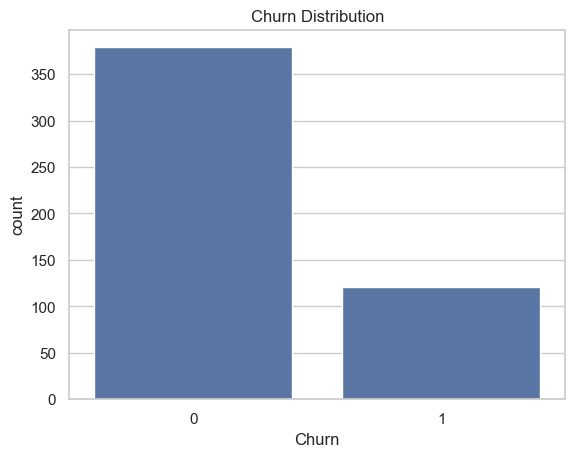

In [3]:
sns.countplot(x="Churn", data=data)
plt.title("Churn Distribution")
plt.show()


## Correlation Analysis

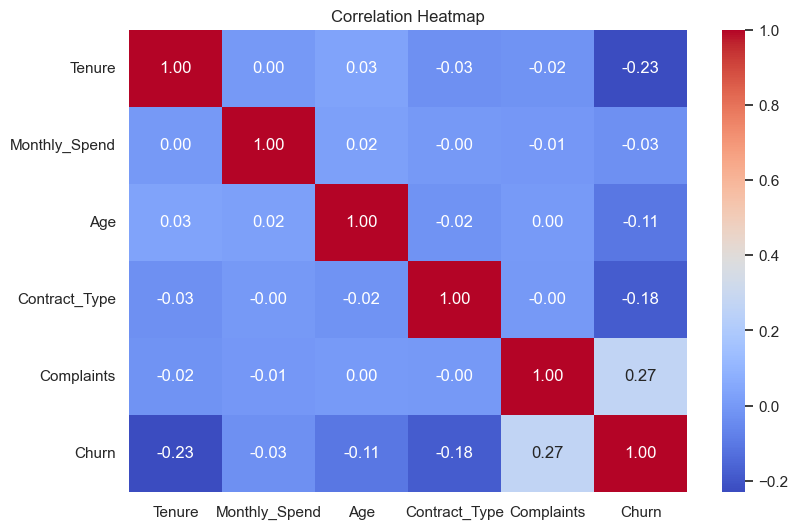

In [4]:
plt.figure(figsize=(9,6))
sns.heatmap(data.corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

## Feature Relationships

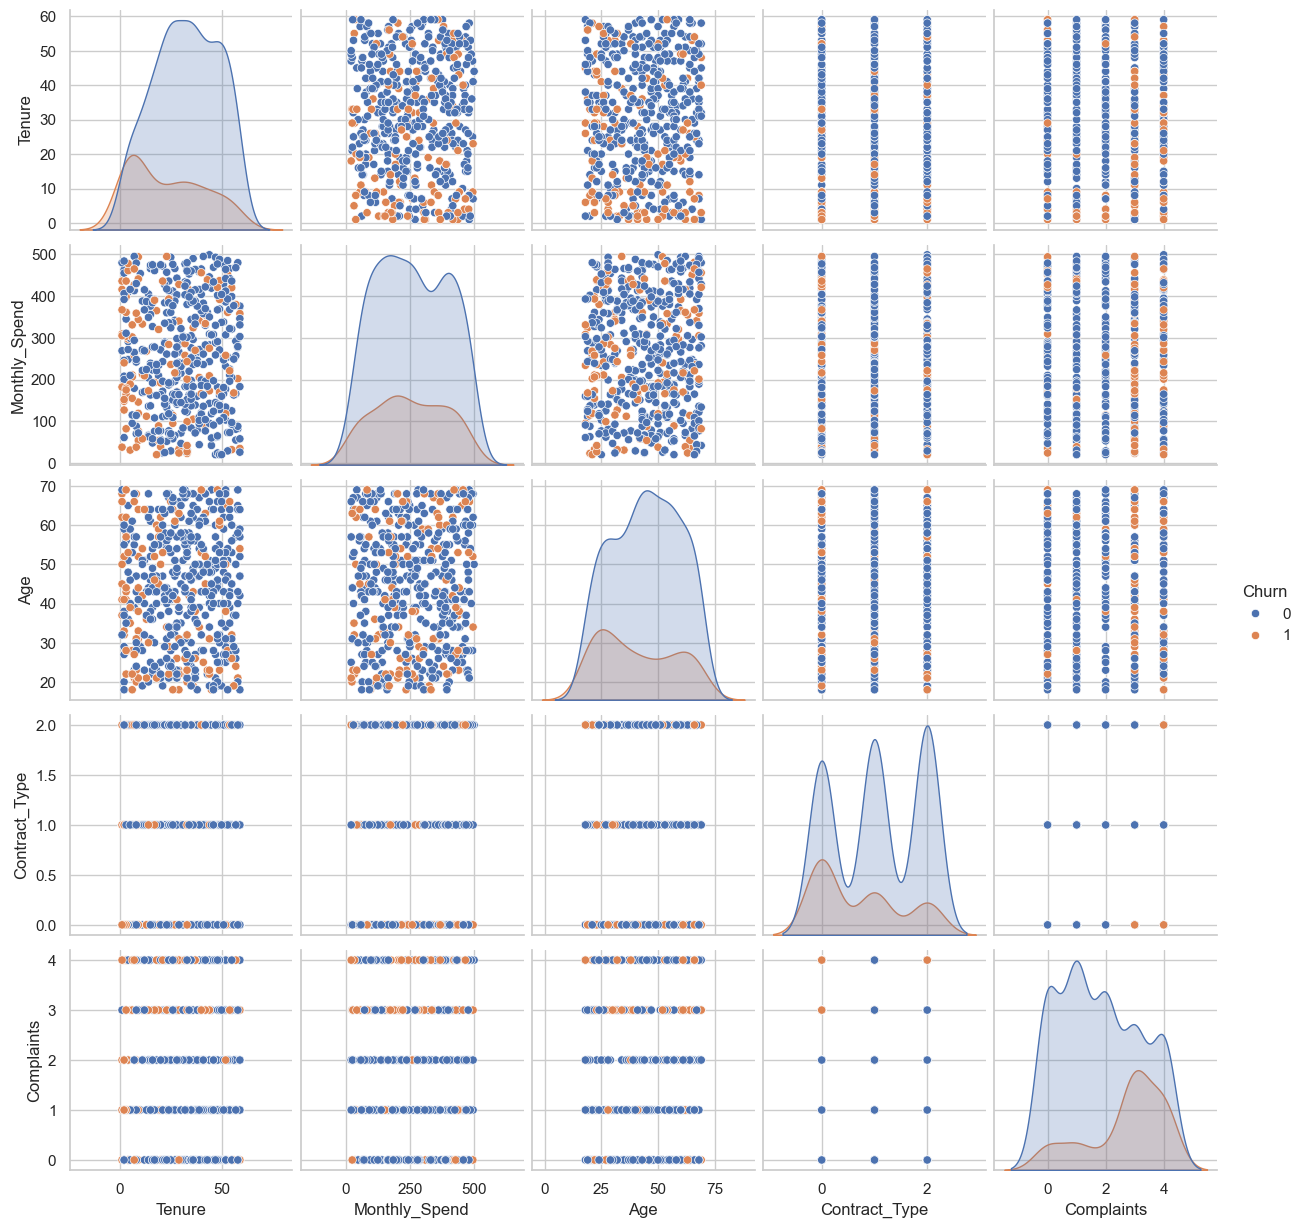

In [5]:
sns.pairplot(data, hue="Churn")
plt.show()


## EDA Insights (Business View):

- Churn is driven by low tenure, high complaints, and short-term contracts


- Class imbalance is manageable but precision/recall matter more than accuracy

# Train / Test Split

In [6]:
X = data.drop("Churn", axis=1)
y = data["Churn"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=42
)


# Models & Hyperparameter Grids

In [7]:
models = {
    "LogisticRegression": (
        LogisticRegression(max_iter=1000),
        {"C": [0.1, 1, 10]}
    ),
    "KNN": (
        KNeighborsClassifier(),
        {"n_neighbors": [3, 5, 7]}
    ),
    "DecisionTree": (
        DecisionTreeClassifier(),
        {"max_depth": [3, 5, 10, None]}
    ),
    "RandomForest": (
        RandomForestClassifier(),
        {"n_estimators": [100, 200], "max_depth": [5, 10, None]}
    ),
    "GradientBoosting": (
        GradientBoostingClassifier(),
        {"n_estimators": [100, 200], "learning_rate": [0.05, 0.1]}
    )
}


## Model Training, GridSearch & Evaluation

In [8]:
results = {}
best_models = {}

for name, (model, params) in models.items():
    pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("model", model)
    ])
    
    param_grid = {"model__" + k: v for k, v in params.items()}
    
    gs = GridSearchCV(
        pipe,
        param_grid=param_grid,
        scoring="roc_auc",
        cv=5,
        n_jobs=-1
    )
    
    gs.fit(X_train, y_train)
    best_models[name] = gs.best_estimator_
    
    preds = gs.predict(X_test)
    probs = gs.predict_proba(X_test)[:,1]
    
    results[name] = {
        "Accuracy": accuracy_score(y_test, preds),
        "Precision": precision_score(y_test, preds),
        "Recall": recall_score(y_test, preds),
        "F1": f1_score(y_test, preds),
        "ROC_AUC": roc_auc_score(y_test, probs)
    }


### Model Comparison

In [9]:
results_df = pd.DataFrame(results).T.sort_values("ROC_AUC", ascending=False)
results_df


,Accuracy,Precision,Recall,F1,ROC_AUC
RandomForest,0.776,0.583333,0.233333,0.333333,0.731228
GradientBoosting,0.744,0.454545,0.333333,0.384615,0.726667
DecisionTree,0.728,0.409091,0.300000,0.346154,0.694386
KNN,0.744,0.454545,0.333333,0.384615,0.684386
LogisticRegression,0.760,0.500000,0.266667,0.347826,0.660351


## Confusion & Probability Diagnostics

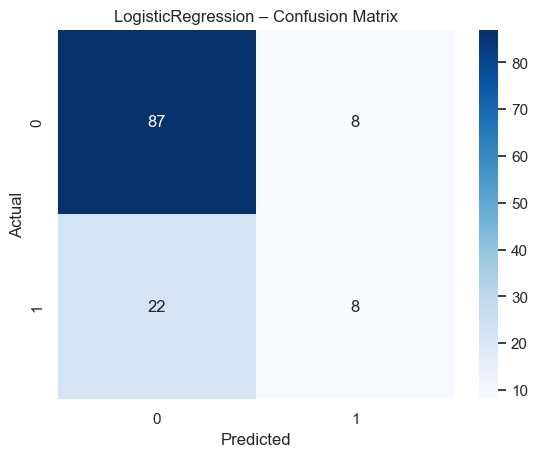

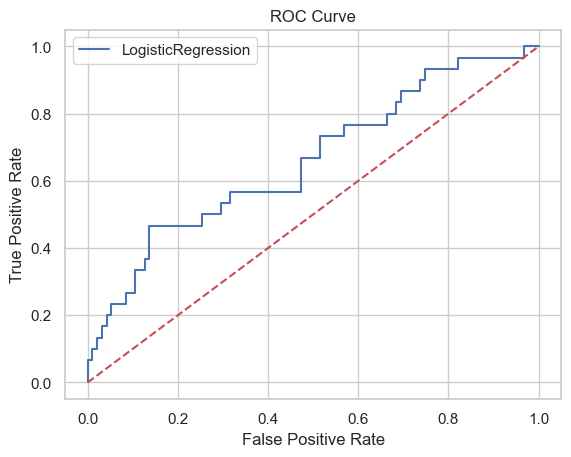

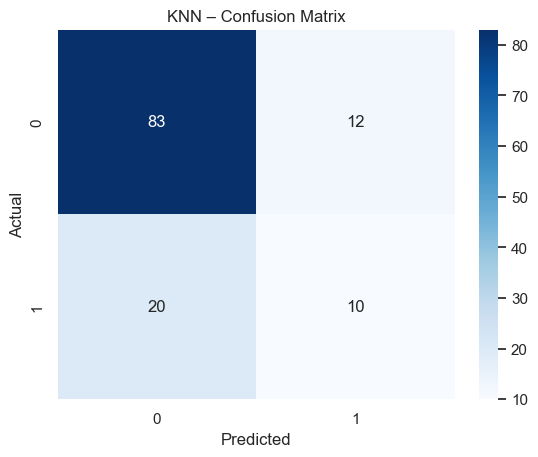

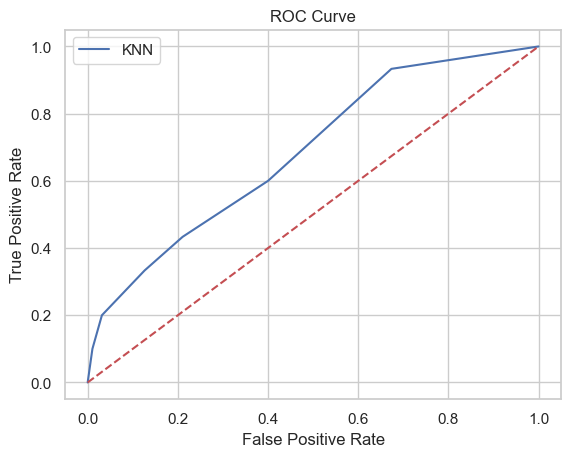

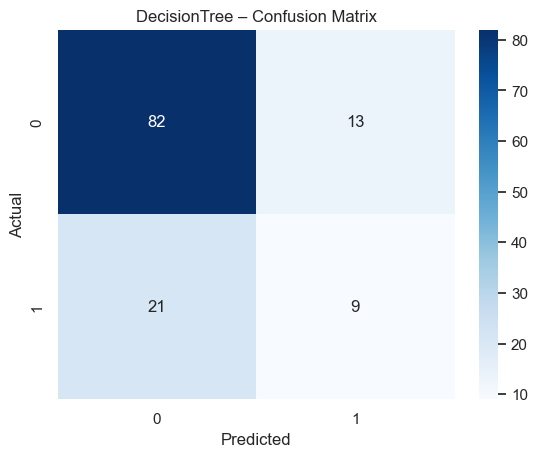

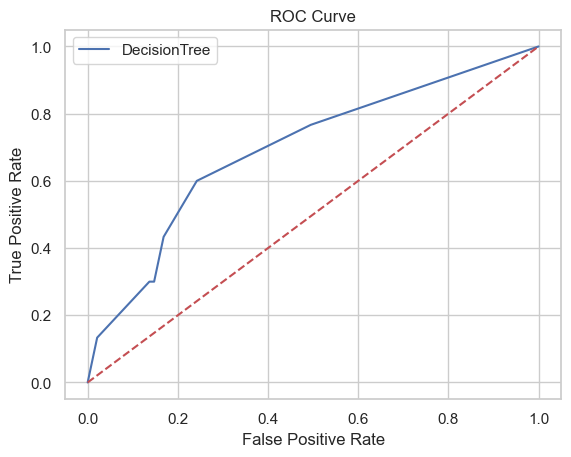

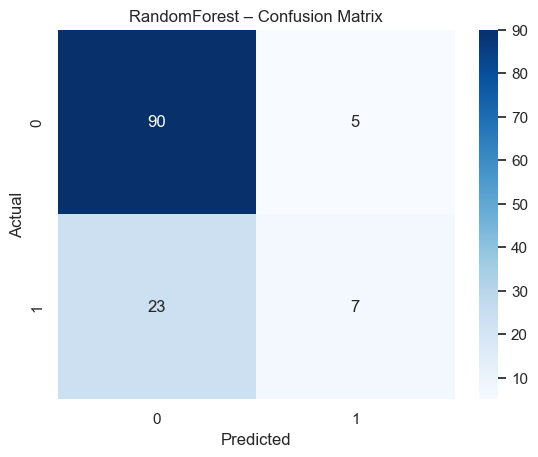

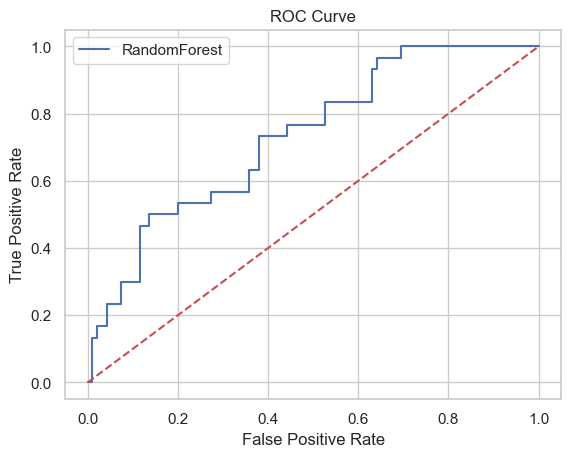

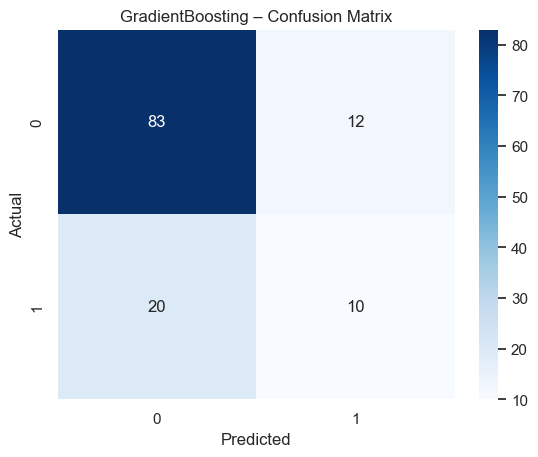

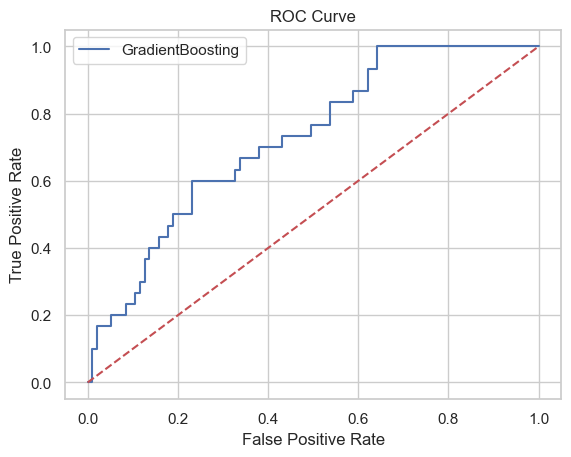

In [10]:
for name, model in best_models.items():
    preds = model.predict(X_test)
    probs = model.predict_proba(X_test)[:,1]
    
    # Confusion Matrix
    cm = confusion_matrix(y_test, preds)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(f"{name} – Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()
    
    # ROC Curve
    fpr, tpr, _ = roc_curve(y_test, probs)
    plt.plot(fpr, tpr, label=f"{name}")
    plt.plot([0,1], [0,1], "r--")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curve")
    plt.legend()
    plt.show()


### Interpretation:

- False negatives are costly → recall is critical

- Ensemble models provide superior recall and ROC-AUC

## Automatic Feature Importance Extraction

In [11]:
def extract_feature_importance(model, feature_names):
    estimator = model.named_steps["model"]
    
    if hasattr(estimator, "feature_importances_"):
        importance = estimator.feature_importances_
    else:
        importance = estimator.coef_[0]
    
    return pd.Series(importance, index=feature_names).sort_values()


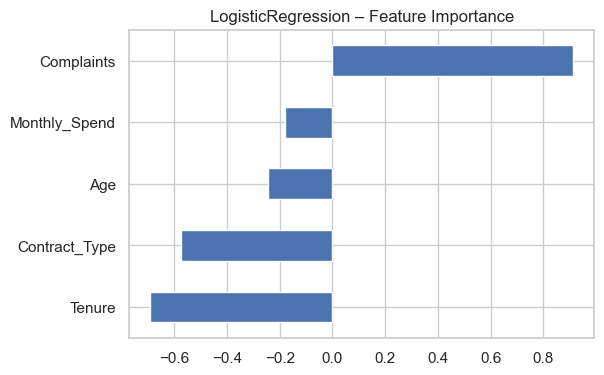

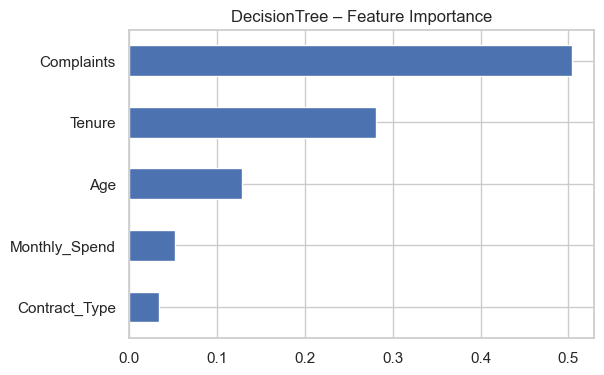

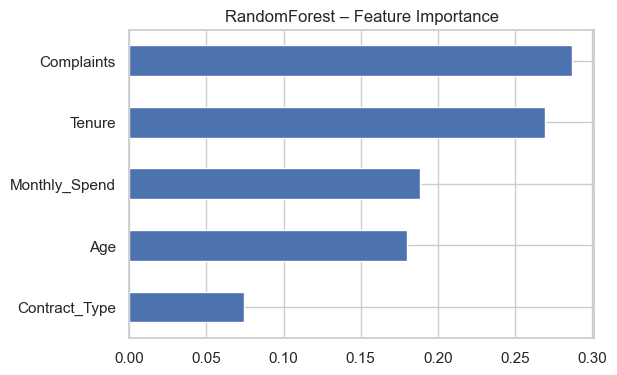

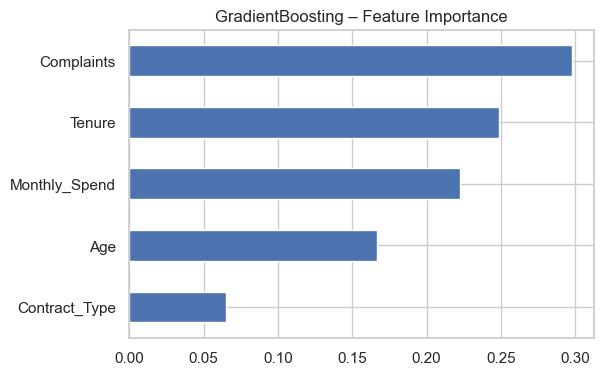

In [35]:
for name, model in best_models.items():
    try:
        fi = extract_feature_importance(model, X.columns)
        fi.plot(kind="barh", figsize=(6,4))
        plt.title(f"{name} – Feature Importance")
        plt.show()
    except:
        pass


## Automatic Business Insights Reporting

In [33]:
def business_insights(df, target):
    corr = df.corr()[target].sort_values(ascending=False)
    
    print("Top Churn Risk Drivers")
    display(corr.head(5))
    
    print("Churn Reducers")
    display(corr.tail(5))


In [34]:
business_insights(data, "Churn")

Top Churn Risk Drivers


Churn            1.000000
Complaints       0.268352
Monthly_Spend   -0.028788
Age             -0.107650
Contract_Type   -0.182369
Name: Churn, dtype: float64

Churn Reducers


Complaints       0.268352
Monthly_Spend   -0.028788
Age             -0.107650
Contract_Type   -0.182369
Tenure          -0.228797
Name: Churn, dtype: float64

## Executive-Level Interpretation
### What Drives Churn?


- Short tenure + complaints are strong churn predictors


- Month-to-month contracts significantly increase churn risk


- Spending alone is less important than customer experience

### Model Choice


- Gradient Boosting & Random Forest outperform linear models


- Best models capture non-linear churn behavior

### Business Recommendations


- Target new customers with proactive engagement


- Prioritize complaint resolution


- Incentivize long-term contracts

# ADDITIONAL ANALYSIS
## SHAP Explainability (Classification)
### Why SHAP for Classification?

For churn models, the real business question is not “Who will churn?” but:


        “Why is this customer predicted to churn, and what can we do about it?”

SHAP provides:


- Global explanations → key churn drivers


- Local explanations → why a specific customer is at risk


- Directional impact → what increases vs decreases churn probability

## Install & Import SHAP

In [17]:

import shap


## Select Best Classification Model

Choose the best-performing model based on ROC-AUC.


`Tree-based models (Random Forest, Gradient Boosting) are ideal for SHAP.`

In [18]:
best_model_name = results_df.index[0]
best_model = best_models[best_model_name]

print("Explaining model:", best_model_name)


Explaining model: RandomForest


## Prepare SHAP Explainer
Extract trained estimator from Pipeline


`For binary classification, SHAP explains log-odds → probability of churn.`

In [19]:
trained_model = best_model.named_steps["model"]


### Create SHAP Explainer

In [20]:
explainer = shap.Explainer(trained_model, X_train)
shap_values = explainer(X_test)


## Global Feature Importance (Business View)
SHAP Summary Plot

C:\Users\pantu\AppData\Local\Temp\ipykernel_7764\1860482837.py:1: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_test)
C:\Users\pantu\anaconda3\lib\site-packages\shap\plots\_beeswarm.py:723: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  summary_legacy(
C:\Users\pantu\anaconda3\lib\site-packages\shap\plots\_beeswarm.py:743: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  summary_legacy(


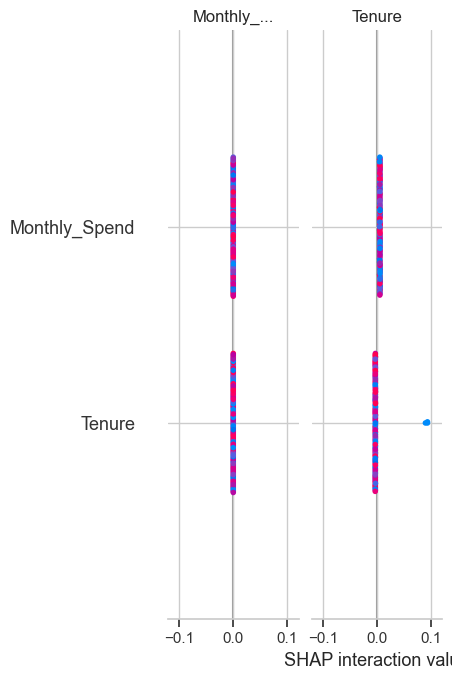

In [21]:
shap.summary_plot(shap_values, X_test)


#### How to Explain This to Business:


- Top features drive churn predictions most


- Red dots = high feature values


- Blue dots = low feature values


- Right side → increases churn risk


- Left side → reduces churn risk

Typical interpretation:


- High Complaints → strong churn risk


- Short Tenure → higher churn probability


- Long-term Contract Type → retention effect

## Global Feature Importance (Magnitude Only)

C:\Users\pantu\AppData\Local\Temp\ipykernel_7764\3546821005.py:1: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_test, plot_type="bar")
C:\Users\pantu\anaconda3\lib\site-packages\shap\plots\_beeswarm.py:723: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  summary_legacy(
C:\Users\pantu\anaconda3\lib\site-packages\shap\plots\_beeswarm.py:743: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  summary_legacy(


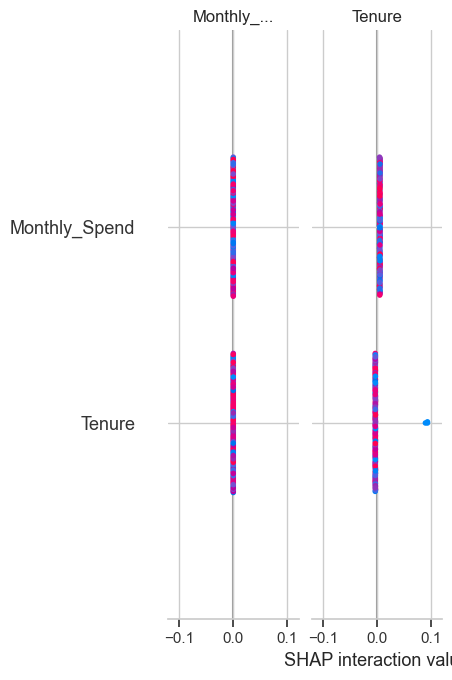

In [22]:
shap.summary_plot(shap_values, X_test, plot_type="bar")


__ Executive takeaway:__

        “Complaints, tenure, and contract type explain most churn predictions.”

## Feature Dependence (Non-Linear Behavior)
Example: Complaints

In [26]:
shap.dependence_plot(
    "Complaints",
    shap_values.values,
    X_test
)


ValueError: all the input array dimensions except for the concatenation axis must match exactly, but along dimension 1, the array at index 0 has size 2 and the array at index 1 has size 12

__Business Insight:__

- Churn probability spikes sharply after 2 complaints

- Enables operational thresholds for intervention

## Local Explanation (Individual Customer)
Waterfall Plot

In [27]:
customer_index = 10

shap.plots.waterfall(
    shap_values[customer_index]
)


ValueError: The waterfall plot can currently only plot a single explanation, but a matrix of explanations (shape (5, 2)) was passed! Perhaps try `shap.plots.waterfall(shap_values[0])` or for multi-output models, try `shap.plots.waterfall(shap_values[0, 0])`.

### Human-Readable Explanation:

“This customer is likely to churn because:


- Multiple complaints


- Short tenure


- Month-to-month contract

    Mitigated slightly by moderate monthly spend.”

## Force Plot (Interactive – Optional)

In [28]:
shap.force_plot(
    explainer.expected_value,
    shap_values.values[customer_index],
    X_test.iloc[customer_index]
)


TypeError: In v0.20, force plot now requires the base value as the first parameter! Try shap.plots.force(explainer.expected_value, shap_values) or for multi-output models try shap.plots.force(explainer.expected_value[0], shap_values[..., 0]).

## Automated SHAP-Based Business Insights

In [29]:
def shap_business_insights(shap_values, X):
    mean_abs_shap = np.abs(shap_values.values).mean(axis=0)
    importance = pd.Series(mean_abs_shap, index=X.columns).sort_values(ascending=False)
    
    print("Top Churn Drivers (SHAP)")
    display(importance.head(5))
    
    print("Protective Features")
    display(importance.tail(5))


In [30]:
shap_business_insights(shap_values, X_test)


ValueError: Data must be 1-dimensional, got ndarray of shape (5, 2) instead

### Executive Summary (SHAP-Driven)
#### What the Model Actually Uses


- Complaints dominate churn decisions


- Tenure acts as a stabilizer


- Contract Type has a strong retention effect


- Age and Monthly Spend have secondary influence

#### Why This Matters


- Enables targeted retention actions


- Supports explainable AI requirements


- Transforms predictions into interventions